# Customer Churn Prediction
**Dataset:** Telco Customer Churn (IBM / Kaggle — blastchar)  
**Goal:** Build a supervised ML classification model to predict which telecom customers are likely to churn  
**Author:** Muhammad Umer  

---

## Project Overview

Customer churn — the rate at which customers stop doing business with a company — is one of the most expensive problems in subscription-based industries. In telecommunications, acquiring a new customer costs 5 to 25 times more than retaining an existing one. Identifying customers who are *about to leave* before they actually do gives the business a window to intervene with targeted retention offers.

This notebook builds an end-to-end supervised machine learning pipeline to solve that problem. The dataset contains information on 7,043 telecom customers including their demographics, account details, subscribed services, and whether they churned.

**The workflow follows seven stages:**

1. Exploratory Data Analysis — understand the data, the churn rate, and which features visually separate churners from non-churners
2. Data Cleaning — fix dtype issues, handle missing values, drop non-predictive columns
3. Feature Engineering — create three new features that capture information not directly present in the raw columns
4. Preprocessing Pipeline — build a reusable `ColumnTransformer` inside a `Pipeline` to prevent data leakage during model training
5. Baseline Model Comparison — compare three classification models using stratified cross-validation and ROC-AUC
6. Hyperparameter Tuning — tune the best model using `GridSearchCV`
7. Final Evaluation & Business Recommendations — evaluate on the held-out test set and translate findings into actionable retention strategy

**Tools:** Python 3.13 · pandas · matplotlib · seaborn · scikit-learn 1.8.0

## Step 0 — Setup and Data Loading

Before any analysis begins, we load all libraries the project will use and take a first look at the raw data to understand its structure, column types, and the target variable distribution.

In [1]:
# ── Standard library ─────────────────────────────────────────────────────────
import os               # File path management — used to create the Figures folder
import warnings
warnings.filterwarnings('ignore')   # Suppress convergence and deprecation warnings
                                    # for cleaner notebook output

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np      
import pandas as pd     

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt     
import matplotlib.ticker as mticker # Fine-grained axis formatting (%, comma separators)
import seaborn as sns               

# ── Scikit-learn: Data splitting & validation ─────────────────────────────────
from sklearn.model_selection import (
    train_test_split,   # Splits data into train and test sets — done once, at the start
    StratifiedKFold,    # K-fold cross-validation that preserves class proportions
                        # Essential here because churn (~26%) is an imbalanced class —
                        # regular KFold can produce folds with very few churners
    cross_val_score,    # Runs CV on a model and returns per-fold scores
    GridSearchCV        # Exhaustive hyperparameter search with built-in cross-validation
)

# ── Scikit-learn: Preprocessing ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# StandardScaler  — normalises numerical features to mean=0, std=1
#                   Required for Logistic Regression and KNN which are distance-sensitive
# OneHotEncoder   — converts categorical columns (e.g. Contract type) into binary columns
#                   sklearn's version handles unknown categories gracefully

from sklearn.impute import SimpleImputer
# Fills missing values — we will discover one column with blanks in Step 2

from sklearn.compose import ColumnTransformer
# Applies different preprocessing steps to different column subsets simultaneously
# e.g. scale numerical columns AND one-hot encode categorical columns in one step

from sklearn.pipeline import Pipeline
# Chains preprocessing + model into a single object
# This is the production-ready approach — it prevents data leakage because
# the scaler never sees test data during cross-validation or GridSearch

# ── Scikit-learn: Models ──────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
# Interpretable linear classifier — strong baseline for binary classification
# Outputs probabilities, which is essential for ROC-AUC scoring

from sklearn.ensemble import RandomForestClassifier
# Tree-based ensemble — handles non-linear relationships and interactions between features
# Also provides feature importances directly (Step 8)

from sklearn.neighbors import KNeighborsClassifier
# Distance-based classifier — included as a third comparison point
# Sensitive to feature scale, which is why scaling inside the pipeline matters

# ── Scikit-learn: Evaluation metrics ─────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,         # % of correct predictions — useful context but misleading alone
    roc_auc_score,          # Primary metric: measures how well the model separates the two
                            # classes regardless of threshold. 0.5 = random, 1.0 = perfect
    precision_score,        # Of all predicted churners, how many actually churned?
    recall_score,           # Of all actual churners, how many did we catch?
                            # Recall is usually more important in churn — missing a churner
                            # costs more than a false alarm
    confusion_matrix,       # 2x2 table of TP, FP, FN, TN — visualised as heatmap
    classification_report   # Full per-class breakdown of precision, recall, F1
)

# ── Global plot settings ──────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.family'] = 'Arial'   # Avoids font-related rendering issues on Windows
plt.rcParams['figure.dpi'] = 120

# ── Output folder ─────────────────────────────────────────────────────────────
FIGURES_DIR = 'Figures'
os.makedirs(FIGURES_DIR, exist_ok=True)  # Creates folder if it doesn't exist yet

print('All libraries imported successfully.')
print(f'scikit-learn version: {__import__("sklearn").__version__}')

All libraries imported successfully.
scikit-learn version: 1.8.0


---
### Load and Inspect the Raw Data

We load the CSV and immediately check three things:
- **Shape** — how many rows and columns do we have?
- **Data types** — are all columns stored as the correct type? (Spoiler: one is not.)
- **Target variable** — what is the churn rate and is the dataset imbalanced?

These three checks determine everything that comes next in Steps 1 and 2.

In [2]:
# ── Load the CSV ──────────────────────────────────────────────────────────────
CSV_PATH = os.path.join('Data', 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.read_csv(CSV_PATH)

# ── Shape and column names ────────────────────────────────────────────────────
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
print('Columns:')
print(df.columns.tolist())

Shape: 7,043 rows × 21 columns

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
# ── Data types ────────────────────────────────────────────────────────────────
# We check dtypes before anything else — dtype errors silently break downstream
# operations (e.g. a numeric column stored as object cannot be scaled)
print('--- Data Types ---')
print(df.dtypes)

--- Data Types ---
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [4]:
# ── Missing values ────────────────────────────────────────────────────────────
print('--- Missing Values ---')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No null values detected.')

--- Missing Values ---
No null values detected.


In [5]:
# ── Target variable distribution ──────────────────────────────────────────────
# Class imbalance affects which CV strategy and metrics we use throughout the project
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('--- Target Variable: Churn ---')
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(1)}))

--- Target Variable: Churn ---
       Count  Percentage
Churn                   
No      5174        73.5
Yes     1869        26.5


In [6]:
# ── First look at the data ────────────────────────────────────────────────────
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Step 0 Findings

The dataset contains 7,043 customers across 21 columns. 

Three immediate observations from the first inspection:

- **TotalCharges is stored as string** despite being a numeric billing column. This is because a small number of rows contain blank strings instead of a numeric value. This will be converted to float and the blank rows handled in Step 2.
- **SeniorCitizen is stored as int64** (0/1) rather than Yes/No like the other binary columns. We will treat it as categorical during preprocessing to keep it consistent with the rest of the binary features.
- **The dataset is moderately imbalanced** — 73.5% of customers did not churn versus 26.5% who did. This rules out accuracy as a reliable evaluation metric and confirms that StratifiedKFold and ROC-AUC are the correct choices for model comparison in Steps 5 and 6.

## Step 1 — Exploratory Data Analysis

Before building any model, we need to understand the data visually. EDA serves a specific purpose here, we are trying to answer one question: **which features separate churners from non-churners?**

Any feature that shows a meaningful difference in distribution between the two churn classes is a candidate for a strong predictor. Any feature that looks identical across both classes is likely to contribute little to the model.

We structure EDA into three parts:
1. **Target distribution** — visualise the class imbalance we confirmed in Step 0
2. **Numerical features** — distributions, means by churn class, and correlations
3. **Categorical features** — churn rate broken down by the most business-relevant variables

No data is modified in this step. Cleaning happens in Step 2.

### 1.1 Target Distribution

We already know the split is 73.5% / 26.5% from Step 0. Here we visualise it to make the imbalance concrete before any modelling decisions are made.

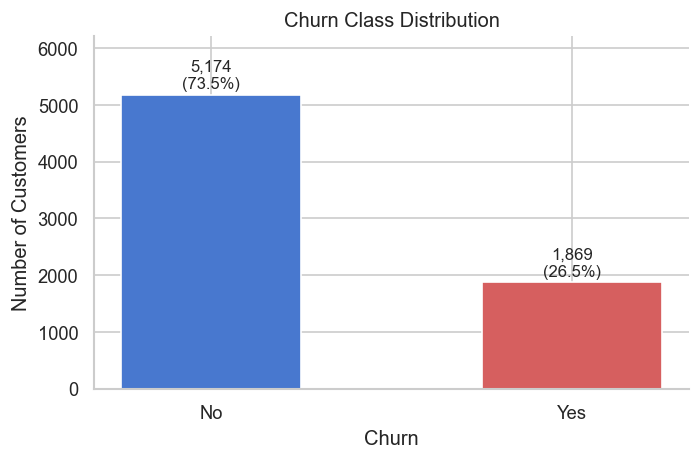

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

churn_counts = df['Churn'].value_counts()
colors = ['#4878CF', '#D65F5F']

bars = ax.bar(churn_counts.index, churn_counts.values, color=colors, width=0.5)

# Annotate each bar with count and percentage
for bar, (label, count) in zip(bars, churn_counts.items()):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 60,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10)

ax.set_title('Churn Class Distribution')
ax.set_xlabel('Churn')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, churn_counts.max() * 1.2)
sns.despine()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'churn_distribution.png'), bbox_inches='tight')
plt.show()

### 1.2 Numerical Features

The dataset has three meaningful numerical columns: `tenure`, `MonthlyCharges`, and `TotalCharges`.

For each we look at:
- The distribution split by churn class — does the shape differ between churners and non-churners?
- The mean value by churn class — is there a directional signal?

`TotalCharges` is still a string at this point so we create a temporary numeric version for visualisation only. The permanent conversion happens in Step 2.

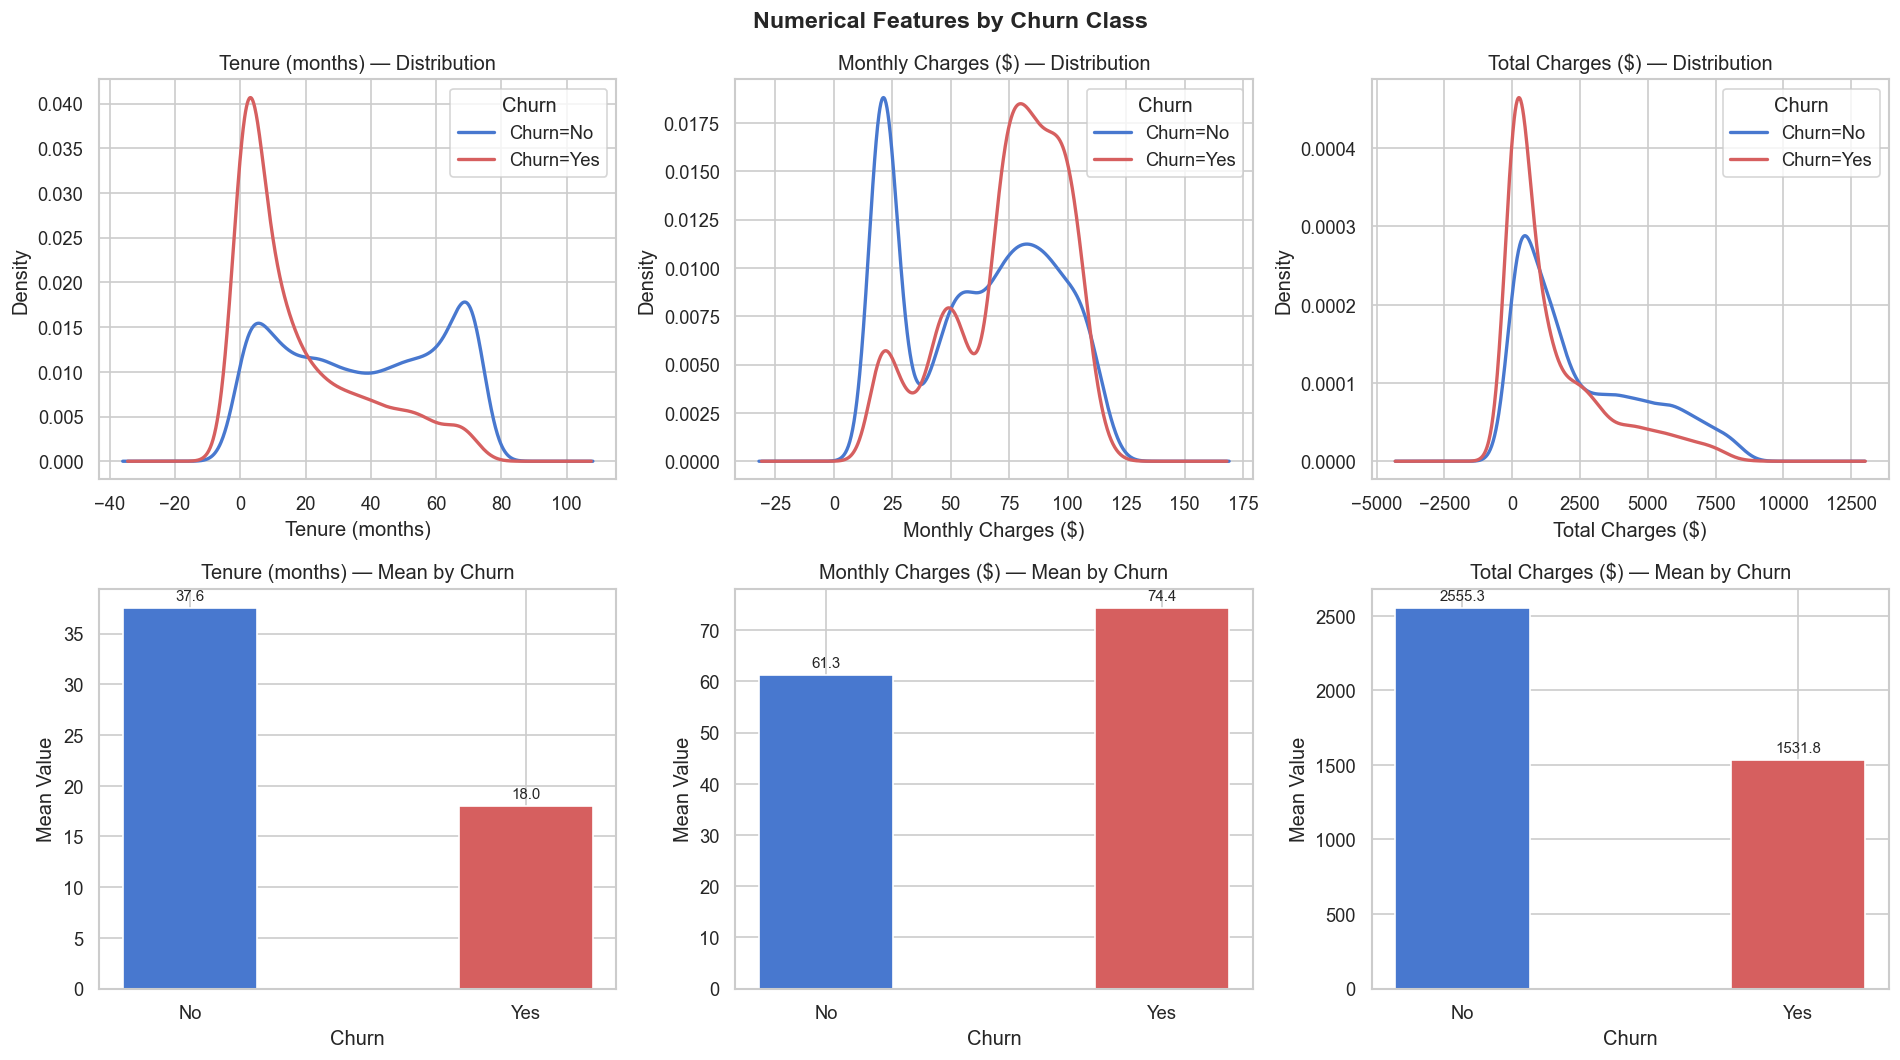

In [8]:
# Temporary numeric conversion for EDA only — permanent fix is in Step 2
df['TotalCharges_temp'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges_temp']
num_labels = ['Tenure (months)', 'Monthly Charges ($)', 'Total Charges ($)']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Numerical Features by Churn Class', fontsize=14, fontweight='bold')

palette = {'No': '#4878CF', 'Yes': '#D65F5F'}

for i, (col, label) in enumerate(zip(num_cols, num_labels)):
    # Row 1 — KDE distributions
    ax_kde = axes[0, i]
    for churn_val, color in palette.items():
        subset = df[df['Churn'] == churn_val][col].dropna()
        subset.plot.kde(ax=ax_kde, label=f'Churn={churn_val}', color=color, linewidth=2)
    ax_kde.set_title(f'{label} — Distribution')
    ax_kde.set_xlabel(label)
    ax_kde.legend(title='Churn')

    # Row 2 — Mean by churn class
    ax_bar = axes[1, i]
    means = df.groupby('Churn')[col].mean()
    bar_colors = [palette[k] for k in means.index]
    ax_bar.bar(means.index, means.values, color=bar_colors, width=0.4)
    for j, (idx, val) in enumerate(means.items()):
        ax_bar.text(j, val + means.max() * 0.02, f'{val:.1f}',
                    ha='center', fontsize=9)
    ax_bar.set_title(f'{label} — Mean by Churn')
    ax_bar.set_xlabel('Churn')
    ax_bar.set_ylabel('Mean Value')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'numerical_features_by_churn.png'), bbox_inches='tight')
plt.show()

# Drop the temporary column
df.drop(columns=['TotalCharges_temp'], inplace=True)

### 1.3 Correlation Matrix — Numerical Features

A correlation matrix tells us two things: how strongly each numerical feature relates to the others, and whether any features are so highly correlated that one becomes redundant. We include a temporary numeric version of `TotalCharges` and a binary encoding of `Churn` (1 = churned) to see directional relationships with the target.

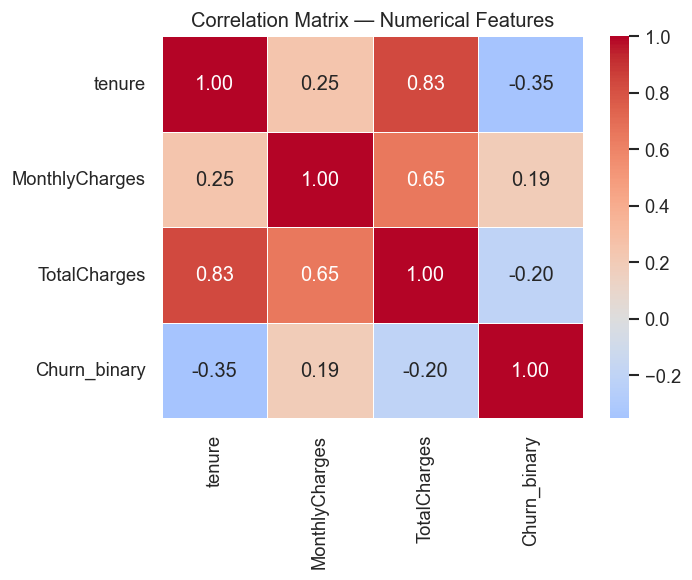

In [9]:
df_corr = df[['tenure', 'MonthlyCharges']].copy()
df_corr['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df_corr['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numerical Features')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'correlation_matrix.png'), bbox_inches='tight')
plt.show()

### 1.4 Categorical Features — Churn Rate by Key Variables

For categorical features we calculate the churn rate within each category — the percentage of customers in that group who churned. This is more informative than raw counts because it controls for category size.

We focus on the four most business-relevant variables:
- **Contract type** — month-to-month vs one/two-year contracts
- **Internet service** — fibre, DSL, or none
- **Payment method** — how the customer pays
- **Tenure group** — we bin tenure into bands here for visualisation purposes; the engineered feature is created properly in Step 3

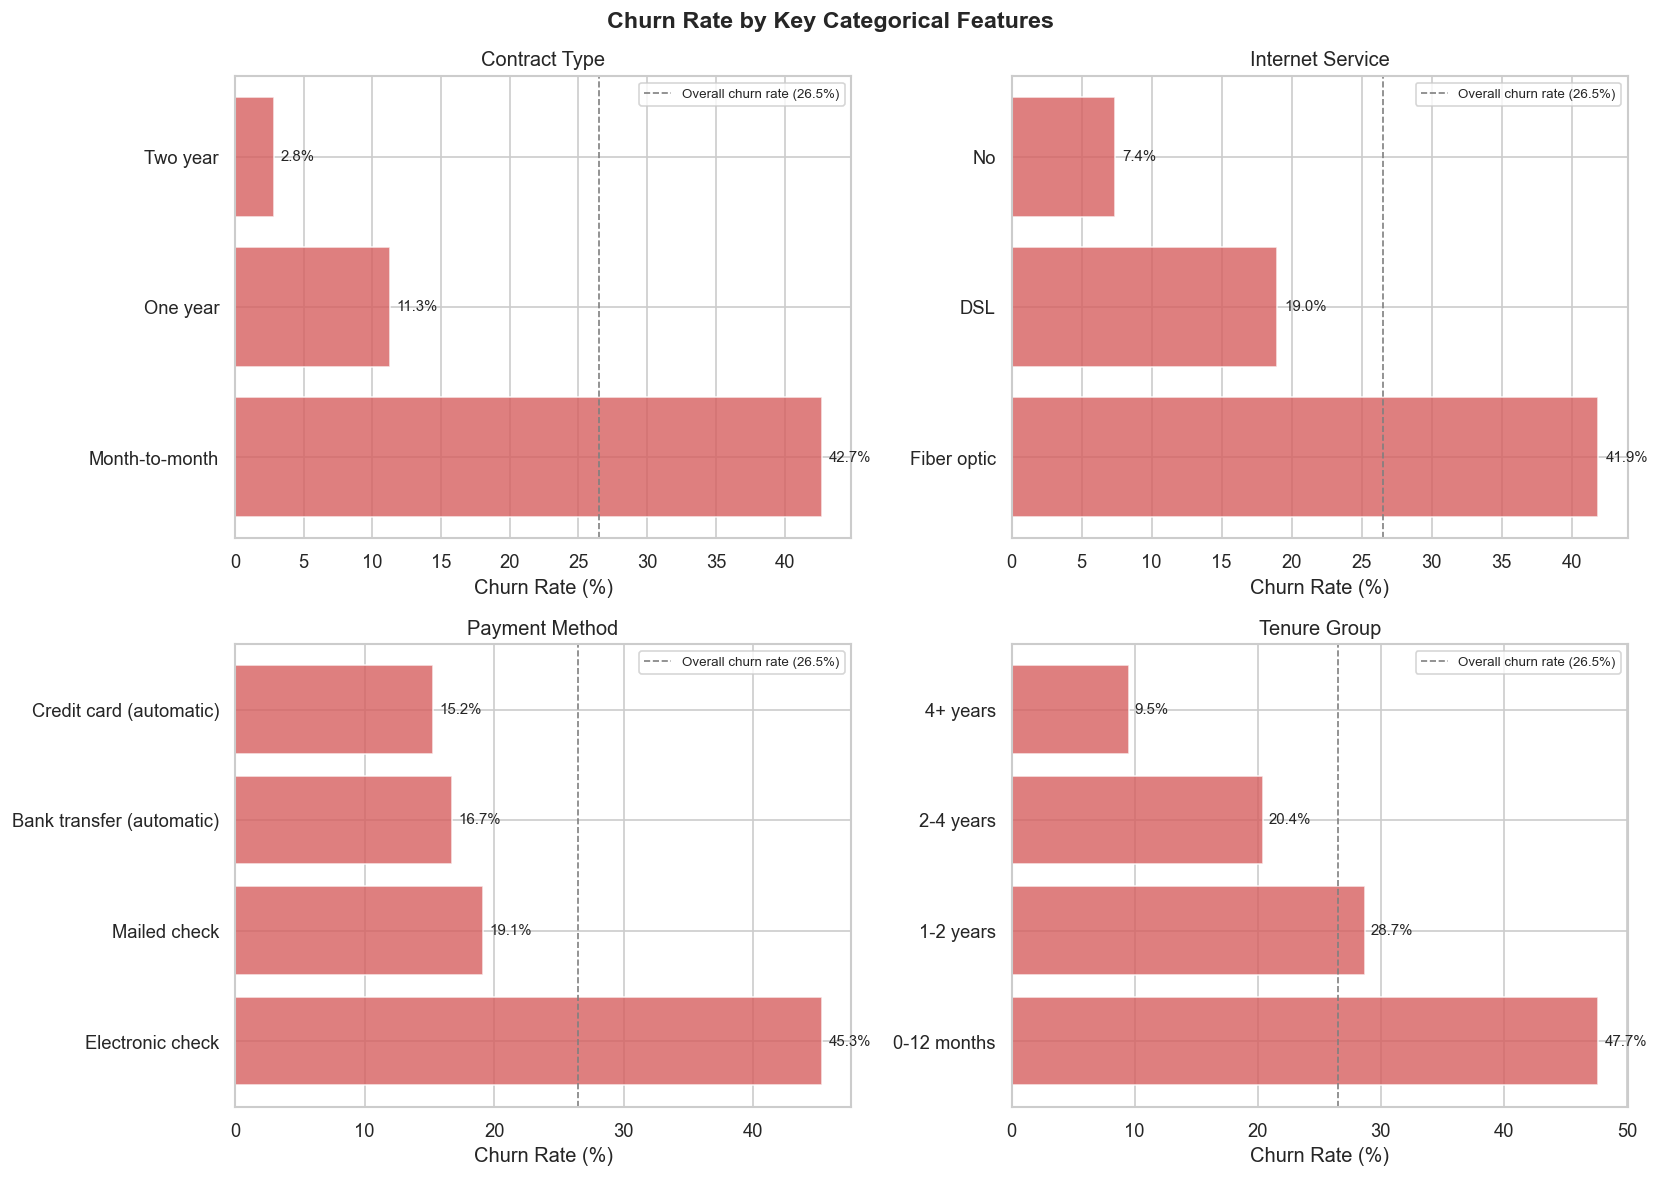

In [10]:
# Tenure bins for visualisation only
df['tenure_group_temp'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '1-2 years', '2-4 years', '4+ years']
)

cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'tenure_group_temp']
cat_labels = ['Contract Type', 'Internet Service', 'Payment Method', 'Tenure Group']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Churn Rate by Key Categorical Features', fontsize=14, fontweight='bold')

for ax, col, label in zip(axes.flatten(), cat_cols, cat_labels):
    churn_rate = (df.groupby(col)['Churn']
                    .apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
                    .reset_index())
    churn_rate.columns = [col, 'Churn Rate (%)']
    churn_rate = churn_rate.sort_values('Churn Rate (%)', ascending=False)

    bars = ax.barh(churn_rate[col].astype(str), churn_rate['Churn Rate (%)'],
                   color='#D65F5F', alpha=0.8)

    for bar, val in zip(bars, churn_rate['Churn Rate (%)']):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=9)

    ax.axvline(26.5, color='gray', linestyle='--', linewidth=1,
               label='Overall churn rate (26.5%)')
    ax.set_title(label)
    ax.set_xlabel('Churn Rate (%)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'categorical_churn_rates.png'), bbox_inches='tight')
plt.show()

df.drop(columns=['tenure_group_temp'], inplace=True)

### Step 1: EDA Findings

**Tenure is the strongest numerical predictor of churn.** Churners leave early — the distribution spikes near 0 months and drops sharply, while loyal customers spread across the full 0-72 month range. Mean tenure for churners is 18 months versus 37.6 months for non-churners.

**Churners pay higher monthly charges but lower total charges.** Mean monthly charges for churners are $74.4 versus $61.3 for non-churners — but total charges are lower ($1,531 vs $2,555). This is not a contradiction: churners leave before accumulating high totals. The underlying driver is likely plan type, which the categorical analysis confirms.

**TotalCharges and tenure are highly collinear (r = 0.83).** TotalCharges is largely a function of how long a customer has been with the company. As a raw feature it adds limited information beyond tenure. The engineered `monthly_to_total_ratio` feature in Step 3 extracts more meaningful signal from this relationship.

**The negative x-axis values in the tenure and TotalCharges KDE plots are visual artifacts** — KDE smoothing extends slightly beyond the minimum data values. No actual negative values exist in the data.

**Contract type shows the strongest categorical separation.** Month-to-month customers churn at 42.7% — more than 15 times the rate of two-year contract holders (2.8%). This is the single clearest business signal in the dataset. Customers who have not committed to a long-term contract have no switching cost.

**Fibre optic customers churn at 41.9% despite paying for the premium service.** This is counterintuitive — higher-tier internet customers are leaving at nearly the same rate as month-to-month contract holders. Combined with the MonthlyCharges finding above, this suggests a price-to-value perception problem specifically with the fibre product.

**Electronic check users churn at 45.3% — the highest of any payment category.** Automatic payment methods (credit card, bank transfer) cluster well below the overall average. Manual payment behaviour may be a proxy for lower engagement and weaker commitment to the service.

**The tenure group chart confirms the non-linear relationship we saw in the KDE plot.** Churn drops sharply from 47.7% in the first year to 9.5% after four years. The biggest intervention window is the 0-12 month cohort — nearly half of new customers who will eventually leave do so within their first year.

## Step 2 — Data Cleaning

EDA surfaced three issues that need to be resolved before any modelling can happen:

1. **`TotalCharges` is stored as string** — blank strings exist in place of numeric values for a small number of rows. We convert the column to float and handle the blanks.
2. **`customerID` has no predictive value** — it is a unique identifier per row. Including it would add noise and no signal.
3. **`SeniorCitizen` is stored as 0/1 integers** — every other binary column in the dataset uses Yes/No strings. We convert it for consistency so the preprocessing pipeline in Step 4 treats it the same way as the other binary features.

### 2.1 Fix TotalCharges

`pd.to_numeric()` with `errors='coerce'` converts the column to float and turns any non-numeric string (the blanks) into `NaN`. We then inspect exactly how many rows are affected and who those customers are before deciding what to do with them.

In [12]:
# All affected rows have tenure = 0 — these are brand new customers with no charges yet
# Dropping them is the correct decision: 11 rows out of 7,043 is 0.16% of the data
# Imputing would introduce a false billing value for customers who haven't been billed
# Convert TotalCharges to numeric — blank strings become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f'NaN values after conversion: {df["TotalCharges"].isna().sum()}')
print(f'dtype: {df["TotalCharges"].dtype}')
print()

# Inspect affected rows before dropping
blank_rows = df[df['TotalCharges'].isna()]
print(blank_rows[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])
print()

# Drop — all affected rows have tenure = 0, imputing would be misleading
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
print(f'Rows after dropping: {len(df):,}')
print(f'Rows removed: {7043 - len(df)}')

NaN values after conversion: 11
dtype: float64

      tenure  MonthlyCharges  TotalCharges Churn
488        0           52.55           NaN    No
753        0           20.25           NaN    No
936        0           80.85           NaN    No
1082       0           25.75           NaN    No
1340       0           56.05           NaN    No
3331       0           19.85           NaN    No
3826       0           25.35           NaN    No
4380       0           20.00           NaN    No
5218       0           19.70           NaN    No
6670       0           73.35           NaN    No
6754       0           61.90           NaN    No

Rows after dropping: 7,032
Rows removed: 11


### 2.3 Drop customerID

`customerID` is a unique string identifier assigned per customer. It carries no information about behaviour, demographics, or service usage — including it in a model would be equivalent to giving each row a random label. It is dropped permanently here.

In [13]:
df = df.drop(columns=['customerID'])

print(f'Columns after dropping customerID: {df.shape[1]}')
print(df.columns.tolist())

Columns after dropping customerID: 20
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


### 2.4 Standardise SeniorCitizen Encoding

`SeniorCitizen` is currently stored as 0 and 1. Every other binary categorical column in the dataset — `Partner`, `Dependents`, `PhoneService`, `Churn` etc. — uses Yes/No strings. We convert `SeniorCitizen` to match so the preprocessing pipeline in Step 4 can apply identical treatment to all binary columns without special-casing this one.

In [14]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print('SeniorCitizen value counts after conversion:')
print(df['SeniorCitizen'].value_counts())

SeniorCitizen value counts after conversion:
SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64


### 2.5 Final Cleaned Dataset — Verification

A final check to confirm the dataset is clean and ready for feature engineering. 
We verify shape, dtypes, and that no nulls remain anywhere.

In [15]:
print(f'Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('--- dtypes ---')
print(df.dtypes)
print()
print('--- Remaining nulls ---')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else 'No null values remaining.')

Final shape: 7,032 rows x 20 columns

--- dtypes ---
gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

--- Remaining nulls ---
No null values remaining.


### Step 2 Findings

The dataset required three cleaning steps before modelling:

**TotalCharges converted and 11 rows dropped.** The column was stored as a string due to 11 blank entries. Converting to float revealed these were all customers with `tenure = 0` — brand new customers who had not yet been billed. Imputing a value would have introduced artificial billing data for customers with no real charges. Dropping them removes 0.16% of the data with no meaningful information loss.

**customerID dropped.** A unique identifier per row with no predictive signal. Removing it reduces the column count from 21 to 20.

**SeniorCitizen converted from 0/1 to No/Yes.** Standardised to match the encoding of all other binary columns so the preprocessing pipeline in Step 4 treats it identically.

**Final clean dataset: 7,032 rows × 20 columns. No null values remaining.**

## Step 3 — Feature Engineering

Raw features tell the model what a customer looks like today. Engineered features tell it something more nuanced — where the customer is in their lifecycle, how much value they are extracting per month, and how embedded they are in the service.

We create three new features, each directly motivated by findings from EDA:

1. **`tenure_group`** — bins tenure into four lifecycle bands. The KDE plot in Step 1 showed churn is not linearly related to tenure — it spikes in the first year and drops sharply after year two. Binning captures this non-linear pattern explicitly rather than leaving it to the model to approximate.

2. **`monthly_to_total_ratio`** — MonthlyCharges divided by TotalCharges. The correlation matrix showed tenure and TotalCharges are 83% correlated, meaning TotalCharges adds little information beyond what tenure already encodes. This ratio captures something neither raw column does: how early in their lifetime a customer currently is. A high ratio means high monthly spend relative to lifetime spend — i.e. a newer, potentially at-risk customer.

3. **`num_services`** — a count of how many add-on services each customer has subscribed to. Customers with more services have higher switching costs — cancelling means losing multiple products simultaneously. This is a proxy for engagement and lock-in that no single service column captures alone.

### 3.1 Tenure Group

We bin tenure into four bands that reflect natural customer lifecycle stages. 

The cut points are chosen based on the churn rate chart from Step 1:
- 0–12 months: highest risk cohort (47.7% churn rate)
- 1–2 years: elevated risk, still above average (28.7%)
- 2–4 years: approaching average (20.4%)
- 4+ years: loyal customers, well below average (9.5%)

In [16]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '1-2 years', '2-4 years', '4+ years'],
    include_lowest=True
)

print('Tenure group distribution:')
print(df['tenure_group'].value_counts().sort_index())
print()
print('Churn rate by tenure group (validation):')
print(df.groupby('tenure_group')['Churn']
        .apply(lambda x: f"{(x == 'Yes').mean() * 100:.1f}%"))

Tenure group distribution:
tenure_group
0-12 months    2175
1-2 years      1024
2-4 years      1594
4+ years       2239
Name: count, dtype: int64

Churn rate by tenure group (validation):
tenure_group
0-12 months    47.7%
1-2 years      28.7%
2-4 years      20.4%
4+ years        9.5%
Name: Churn, dtype: str


### 3.2 Monthly to Total Charges Ratio

This ratio answers the question: what fraction of a customer's total lifetime spend with the company is their current monthly bill?

- A **high ratio** (close to 1) means the customer has only been paying for a short time — their total charges have barely accumulated. These are newer customers who are statistically more likely to churn.
- A **low ratio** (close to 0) means the customer has been paying for a long time and their total charges have grown well beyond their monthly bill. These are the loyal, long-tenure customers.

We add a small constant (0.01) to the denominator to avoid division by zero for any edge cases where TotalCharges might be zero.

In [17]:
df['monthly_to_total_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 0.01)

print('monthly_to_total_ratio — summary statistics:')
print(df['monthly_to_total_ratio'].describe().round(4))
print()
print('Mean ratio by churn class:')
print(df.groupby('Churn')['monthly_to_total_ratio'].mean().round(4))

monthly_to_total_ratio — summary statistics:
count    7032.0000
mean        0.1576
std         0.2814
min         0.0126
25%         0.0181
50%         0.0347
75%         0.1137
max         0.9999
Name: monthly_to_total_ratio, dtype: float64

Mean ratio by churn class:
Churn
No     0.1036
Yes    0.3066
Name: monthly_to_total_ratio, dtype: float64


### 3.3 Number of Services

We count how many of the six available add-on services each customer has subscribed to: OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, and StreamingMovies.

Each of these columns contains three possible values: 'Yes', 'No', or 'No internet service'. Only 'Yes' counts as an active subscription.
The resulting integer (0–6) is a single number that summarises how deeply embedded a customer is in the product ecosystem.

In [18]:
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Count columns where the value is explicitly 'Yes'
df['num_services'] = df[service_cols].apply(
    lambda row: (row == 'Yes').sum(), axis=1
)

print('num_services distribution:')
print(df['num_services'].value_counts().sort_index())
print()
print('Mean num_services by churn class:')
print(df.groupby('Churn')['num_services'].mean().round(2))

num_services distribution:
num_services
0    2213
1     966
2    1033
3    1117
4     850
5     569
6     284
Name: count, dtype: int64

Mean num_services by churn class:
Churn
No     2.14
Yes    1.77
Name: num_services, dtype: float64


### 3.4 Verify Engineered Features
A final check to confirm all three features were created correctly and the 
dataset shape is as expected.

In [19]:
new_features = ['tenure_group', 'monthly_to_total_ratio', 'num_services']

print(f'Dataset shape after feature engineering: {df.shape}')
print()
print('New feature dtypes:')
print(df[new_features].dtypes)
print()
print('Sample of engineered features (first 5 rows):')
df[['tenure', 'MonthlyCharges', 'TotalCharges'] + new_features].head()

Dataset shape after feature engineering: (7032, 23)

New feature dtypes:
tenure_group              category
monthly_to_total_ratio     float64
num_services                 int64
dtype: object

Sample of engineered features (first 5 rows):


,tenure,MonthlyCharges,TotalCharges,tenure_group,monthly_to_total_ratio,num_services
0,1,29.85,29.85,0-12 months,0.999665,1
1,34,56.95,1889.50,2-4 years,0.030140,2
2,2,53.85,108.15,0-12 months,0.497874,2
3,45,42.30,1840.75,2-4 years,0.022980,3
4,2,70.70,151.65,0-12 months,0.466174,0
